# Variance Analysis: Optuna vs Empirical Approach

This notebook compares the variance in episode length and reward mean between the Optuna hyperparameter optimization approach and the empirical approach across 3 replicates.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up paths - use relative paths from notebook location
notebook_dir = Path.cwd()
base_path = notebook_dir

empirical_len_path = base_path / 'episode_len_mean' / 'empirical_len'
optuna_len_path = base_path / 'episode_len_mean' / 'optuna_len'
empirical_rew_path = base_path / 'episode_rew_mean' / 'empirical_rew'
optuna_rew_path = base_path / 'episode_rew_mean' / 'optuna_rew'

print(f"Working directory: {notebook_dir}")

Working directory: /home/vydi/challenge1__5/variance_analysis


In [42]:
# Load empirical episode length data
empirical_len_data = {}
for file in empirical_len_path.glob('*.csv'):
    # Extract replicate number correctly - find the number after 'replicate_'
    filename = file.stem
    replicate_match = filename.split('replicate_')[1].split('_')[0]  # Get number after 'replicate_'
    empirical_len_data[f'empirical_{replicate_match}'] = pd.read_csv(file)

# Load optuna episode length data
optuna_len_data = {}
for file in optuna_len_path.glob('*.csv'):
    # Extract replicate number correctly - find the number after 'replicate_'
    filename = file.stem
    replicate_match = filename.split('replicate_')[1].split('_')[0]  # Get number after 'replicate_'
    optuna_len_data[f'optuna_{replicate_match}'] = pd.read_csv(file)

# Load empirical episode reward data
empirical_rew_data = {}
for file in empirical_rew_path.glob('*.csv'):
    # Extract replicate number correctly - find the number after 'replicate_'
    filename = file.stem
    replicate_match = filename.split('replicate_')[1].split('_')[0]  # Get number after 'replicate_'
    empirical_rew_data[f'empirical_{replicate_match}'] = pd.read_csv(file)

# Load optuna episode reward data
optuna_rew_data = {}
for file in optuna_rew_path.glob('*.csv'):
    # Extract replicate number correctly - find the number after 'replicate_'
    filename = file.stem
    replicate_match = filename.split('replicate_')[1].split('_')[0]  # Get number after 'replicate_'
    optuna_rew_data[f'optuna_{replicate_match}'] = pd.read_csv(file)

print("Loaded data shapes:")
print(f"Empirical length replicates: {len(empirical_len_data)}")
print(f"Optuna length replicates: {len(optuna_len_data)}")
print(f"Empirical reward replicates: {len(empirical_rew_data)}")
print(f"Optuna reward replicates: {len(optuna_rew_data)}")
print("\nLoaded replicate names:")
print(f"Empirical length: {list(empirical_len_data.keys())}")
print(f"Optuna length: {list(optuna_len_data.keys())}")
print(f"Empirical reward: {list(empirical_rew_data.keys())}")
print(f"Optuna reward: {list(optuna_rew_data.keys())}")

Loaded data shapes:
Empirical length replicates: 3
Optuna length replicates: 3
Empirical reward replicates: 3
Optuna reward replicates: 3

Loaded replicate names:
Empirical length: ['empirical_1', 'empirical_3', 'empirical_2']
Optuna length: ['optuna_3', 'optuna_2', 'optuna_1']
Empirical reward: ['empirical_1', 'empirical_3', 'empirical_2']
Optuna reward: ['optuna_3', 'optuna_2', 'optuna_1']


In [43]:
# Calculate variance metrics for episode length
len_variance_data = {
    'Metric': [],
    'Approach': [],
    'Variance': [],
    'Std Dev': [],
    'Mean': [],
    'Min': [],
    'Max': []
}

# Process empirical length
for replicate_name, df in empirical_len_data.items():
    values = df['Value'].values
    len_variance_data['Metric'].append('Episode Length')
    len_variance_data['Approach'].append('Empirical')
    len_variance_data['Variance'].append(np.var(values))
    len_variance_data['Std Dev'].append(np.std(values))
    len_variance_data['Mean'].append(np.mean(values))
    len_variance_data['Min'].append(np.min(values))
    len_variance_data['Max'].append(np.max(values))

# Process optuna length
for replicate_name, df in optuna_len_data.items():
    values = df['Value'].values
    len_variance_data['Metric'].append('Episode Length')
    len_variance_data['Approach'].append('Optuna')
    len_variance_data['Variance'].append(np.var(values))
    len_variance_data['Std Dev'].append(np.std(values))
    len_variance_data['Mean'].append(np.mean(values))
    len_variance_data['Min'].append(np.min(values))
    len_variance_data['Max'].append(np.max(values))

len_variance_df = pd.DataFrame(len_variance_data)
print("Episode Length Variance Analysis:")
print(len_variance_df.to_string(index=False))
print()

Episode Length Variance Analysis:
        Metric  Approach      Variance    Std Dev        Mean         Min          Max
Episode Length Empirical  47481.500176 217.902502 7355.465037 6670.666504  8416.000000
Episode Length Empirical 243198.952792 493.152058 8093.479313 4922.000000  8775.000000
Episode Length Empirical 205464.936385 453.282402 8150.499083 7363.000000 10699.000000
Episode Length    Optuna 118944.518568 344.883341 7611.258772 6885.047852  9462.000000
Episode Length    Optuna 199429.115110 446.574871 7428.323903 4352.000000  8105.422852
Episode Length    Optuna 223214.432477 472.455747 7495.633439 7017.784180 10753.000000



In [44]:
# Calculate variance metrics for episode reward
rew_variance_data = {
    'Metric': [],
    'Approach': [],
    'Variance': [],
    'Std Dev': [],
    'Mean': [],
    'Min': [],
    'Max': []
}

# Process empirical reward
for replicate_name, df in empirical_rew_data.items():
    values = df['Value'].values
    rew_variance_data['Metric'].append('Episode Reward')
    rew_variance_data['Approach'].append('Empirical')
    rew_variance_data['Variance'].append(np.var(values))
    rew_variance_data['Std Dev'].append(np.std(values))
    rew_variance_data['Mean'].append(np.mean(values))
    rew_variance_data['Min'].append(np.min(values))
    rew_variance_data['Max'].append(np.max(values))

# Process optuna reward
for replicate_name, df in optuna_rew_data.items():
    values = df['Value'].values
    rew_variance_data['Metric'].append('Episode Reward')
    rew_variance_data['Approach'].append('Optuna')
    rew_variance_data['Variance'].append(np.var(values))
    rew_variance_data['Std Dev'].append(np.std(values))
    rew_variance_data['Mean'].append(np.mean(values))
    rew_variance_data['Min'].append(np.min(values))
    rew_variance_data['Max'].append(np.max(values))

rew_variance_df = pd.DataFrame(rew_variance_data)
print("Episode Reward Variance Analysis:")
print(rew_variance_df.to_string(index=False))

Episode Reward Variance Analysis:
        Metric  Approach      Variance    Std Dev        Mean         Min         Max
Episode Reward Empirical  33325.292812 182.552165  810.550507  596.000000 1350.000000
Episode Reward Empirical 149594.636729 386.774659 1075.723398  814.599976 3180.000000
Episode Reward Empirical  54588.957942 233.642800 1169.716776  943.799988 1901.538452
Episode Reward    Optuna 267322.787807 517.032676 1542.451625 1041.400024 3425.000000
Episode Reward    Optuna  36575.848808 191.248134 1363.348685 1140.317505 2120.000000
Episode Reward    Optuna 188900.452075 434.626796 1391.867497  876.799988 2628.000000


In [45]:
# Summary statistics comparison
print("\n" + "="*80)
print("SUMMARY COMPARISON")
print("="*80 + "\n")

print("Episode Length - Average Metrics Across Replicates:")
empirical_len_summary = len_variance_df[len_variance_df['Approach'] == 'Empirical']
optuna_len_summary = len_variance_df[len_variance_df['Approach'] == 'Optuna']

print(f"\nEmpirical:")
print(f"  Mean Variance: {empirical_len_summary['Variance'].mean():.2f}")
print(f"  Mean Std Dev: {empirical_len_summary['Std Dev'].mean():.2f}")
print(f"  Mean Value: {empirical_len_summary['Mean'].mean():.2f}")

print(f"\nOptuna:")
print(f"  Mean Variance: {optuna_len_summary['Variance'].mean():.2f}")
print(f"  Mean Std Dev: {optuna_len_summary['Std Dev'].mean():.2f}")
print(f"  Mean Value: {optuna_len_summary['Mean'].mean():.2f}")

print(f"\nVariance Difference (Optuna - Empirical): {optuna_len_summary['Variance'].mean() - empirical_len_summary['Variance'].mean():.2f}")
print(f"Std Dev Difference (Optuna - Empirical): {optuna_len_summary['Std Dev'].mean() - empirical_len_summary['Std Dev'].mean():.2f}")

print("\n" + "-"*80)
print("Episode Reward - Average Metrics Across Replicates:")
empirical_rew_summary = rew_variance_df[rew_variance_df['Approach'] == 'Empirical']
optuna_rew_summary = rew_variance_df[rew_variance_df['Approach'] == 'Optuna']

print(f"\nEmpirical:")
print(f"  Mean Variance: {empirical_rew_summary['Variance'].mean():.2f}")
print(f"  Mean Std Dev: {empirical_rew_summary['Std Dev'].mean():.2f}")
print(f"  Mean Value: {empirical_rew_summary['Mean'].mean():.2f}")

print(f"\nOptuna:")
print(f"  Mean Variance: {optuna_rew_summary['Variance'].mean():.2f}")
print(f"  Mean Std Dev: {optuna_rew_summary['Std Dev'].mean():.2f}")
print(f"  Mean Value: {optuna_rew_summary['Mean'].mean():.2f}")

print(f"\nVariance Difference (Optuna - Empirical): {optuna_rew_summary['Variance'].mean() - empirical_rew_summary['Variance'].mean():.2f}")
print(f"Std Dev Difference (Optuna - Empirical): {optuna_rew_summary['Std Dev'].mean() - empirical_rew_summary['Std Dev'].mean():.2f}")


SUMMARY COMPARISON

Episode Length - Average Metrics Across Replicates:

Empirical:
  Mean Variance: 165381.80
  Mean Std Dev: 388.11
  Mean Value: 7866.48

Optuna:
  Mean Variance: 180529.36
  Mean Std Dev: 421.30
  Mean Value: 7511.74

Variance Difference (Optuna - Empirical): 15147.56
Std Dev Difference (Optuna - Empirical): 33.19

--------------------------------------------------------------------------------
Episode Reward - Average Metrics Across Replicates:

Empirical:
  Mean Variance: 79169.63
  Mean Std Dev: 267.66
  Mean Value: 1018.66

Optuna:
  Mean Variance: 164266.36
  Mean Std Dev: 380.97
  Mean Value: 1432.56

Variance Difference (Optuna - Empirical): 85096.73
Std Dev Difference (Optuna - Empirical): 113.31


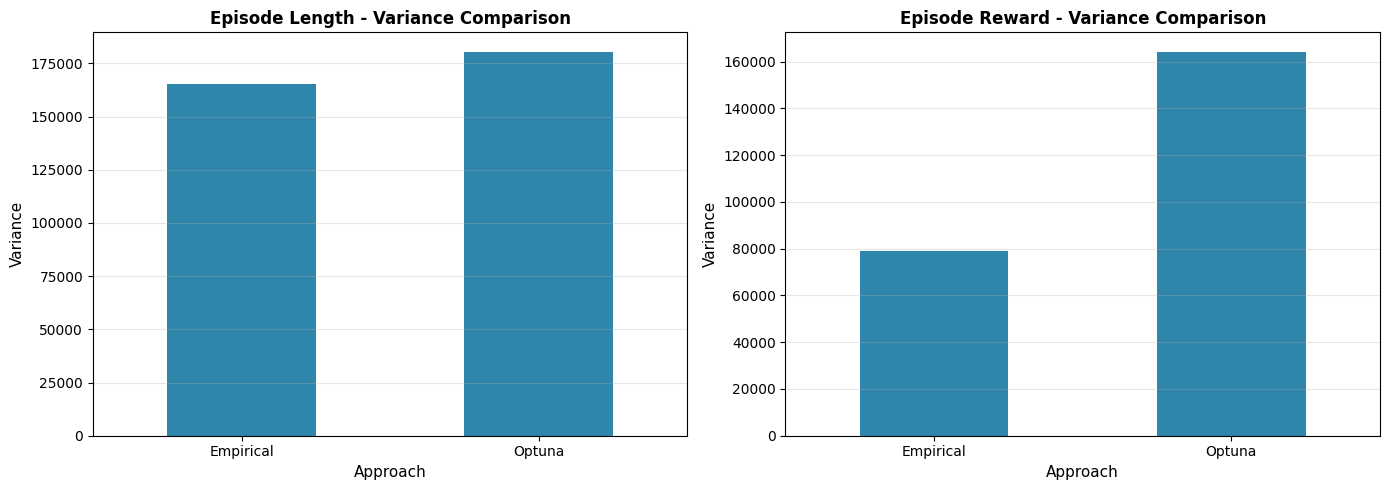

In [36]:
# Visualization: Variance Comparison - Episode Length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Episode Length Variance
ax1 = axes[0]
len_summary = len_variance_df.groupby('Approach')[['Variance']].mean()
len_summary.plot(kind='bar', ax=ax1, color=['#2E86AB', '#A23B72'], legend=False)
ax1.set_title('Episode Length - Variance Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('Variance', fontsize=11)
ax1.set_xlabel('Approach', fontsize=11)
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Episode Reward Variance
ax2 = axes[1]
rew_summary = rew_variance_df.groupby('Approach')[['Variance']].mean()
rew_summary.plot(kind='bar', ax=ax2, color=['#2E86AB', '#A23B72'], legend=False)
ax2.set_title('Episode Reward - Variance Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Variance', fontsize=11)
ax2.set_xlabel('Approach', fontsize=11)
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

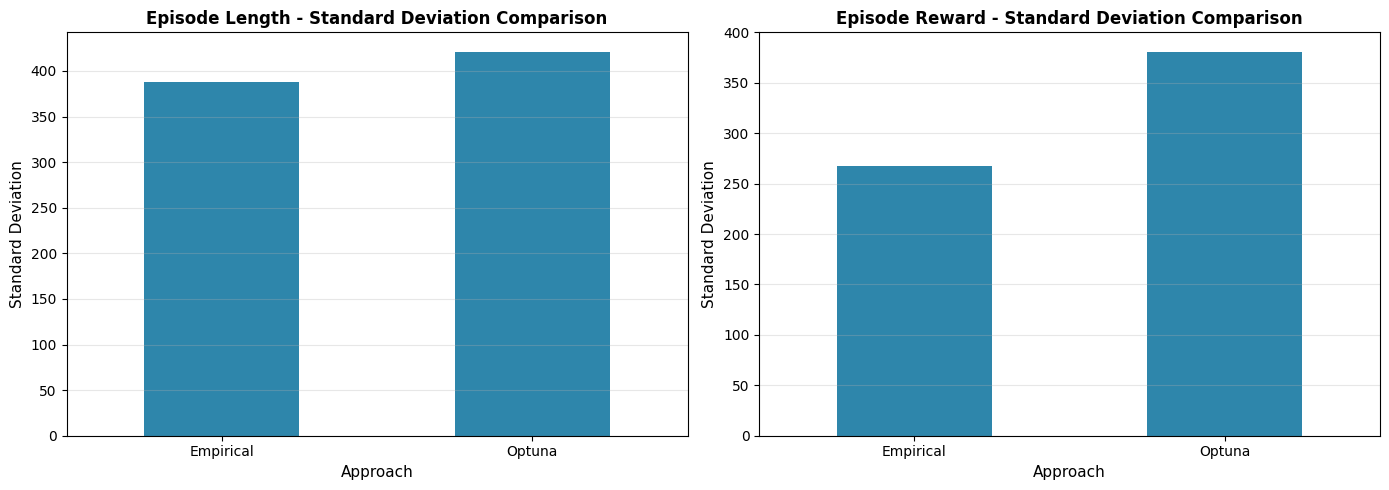

In [37]:
# Visualization: Standard Deviation Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Episode Length Std Dev
ax1 = axes[0]
len_std_summary = len_variance_df.groupby('Approach')[['Std Dev']].mean()
len_std_summary.plot(kind='bar', ax=ax1, color=['#2E86AB', '#A23B72'], legend=False)
ax1.set_title('Episode Length - Standard Deviation Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('Standard Deviation', fontsize=11)
ax1.set_xlabel('Approach', fontsize=11)
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Episode Reward Std Dev
ax2 = axes[1]
rew_std_summary = rew_variance_df.groupby('Approach')[['Std Dev']].mean()
rew_std_summary.plot(kind='bar', ax=ax2, color=['#2E86AB', '#A23B72'], legend=False)
ax2.set_title('Episode Reward - Standard Deviation Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Standard Deviation', fontsize=11)
ax2.set_xlabel('Approach', fontsize=11)
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_121448/3159514051.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot([empirical_len_values, optuna_len_values],
/tmp/ipykernel_121448/3159514051.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot([empirical_rew_values, optuna_rew_values],


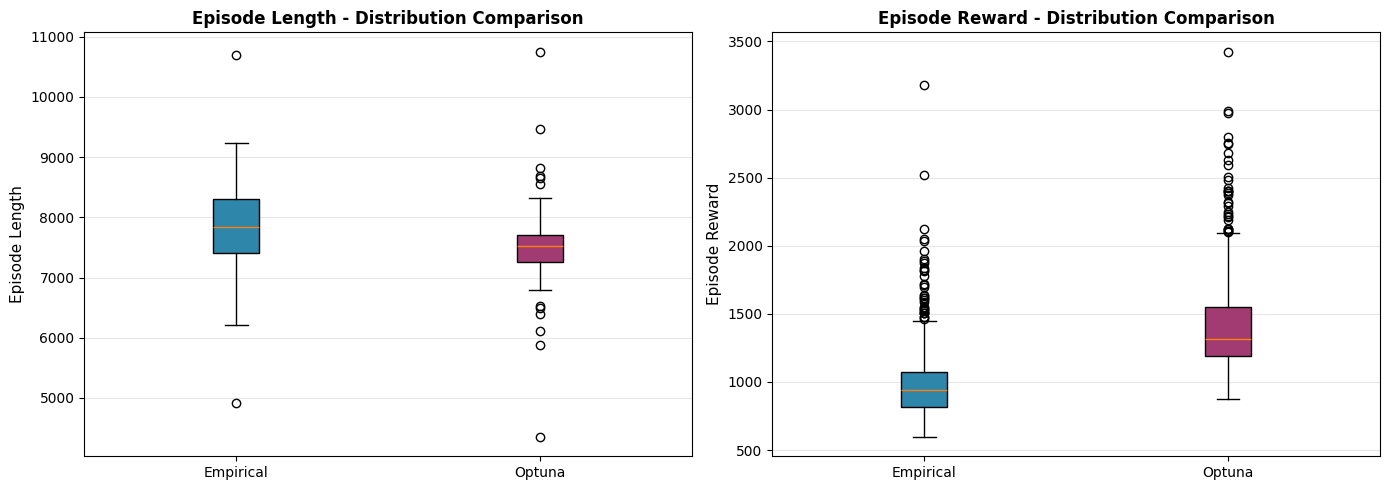

In [38]:
# Visualization: Box Plot Comparison for Episode Length Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data for boxplot
empirical_len_values = []
optuna_len_values = []
empirical_rew_values = []
optuna_rew_values = []

# Collect all values
for df in empirical_len_data.values():
    empirical_len_values.extend(df['Value'].values)
for df in optuna_len_data.values():
    optuna_len_values.extend(df['Value'].values)
for df in empirical_rew_data.values():
    empirical_rew_values.extend(df['Value'].values)
for df in optuna_rew_data.values():
    optuna_rew_values.extend(df['Value'].values)

# Episode Length Box Plot
ax1 = axes[0]
bp1 = ax1.boxplot([empirical_len_values, optuna_len_values], 
                    labels=['Empirical', 'Optuna'],
                    patch_artist=True)
for patch, color in zip(bp1['boxes'], ['#2E86AB', '#A23B72']):
    patch.set_facecolor(color)
ax1.set_title('Episode Length - Distribution Comparison', fontsize=12, fontweight='bold')
ax1.set_ylabel('Episode Length', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Episode Reward Box Plot
ax2 = axes[1]
bp2 = ax2.boxplot([empirical_rew_values, optuna_rew_values], 
                    labels=['Empirical', 'Optuna'],
                    patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#2E86AB', '#A23B72']):
    patch.set_facecolor(color)
ax2.set_title('Episode Reward - Distribution Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Episode Reward', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

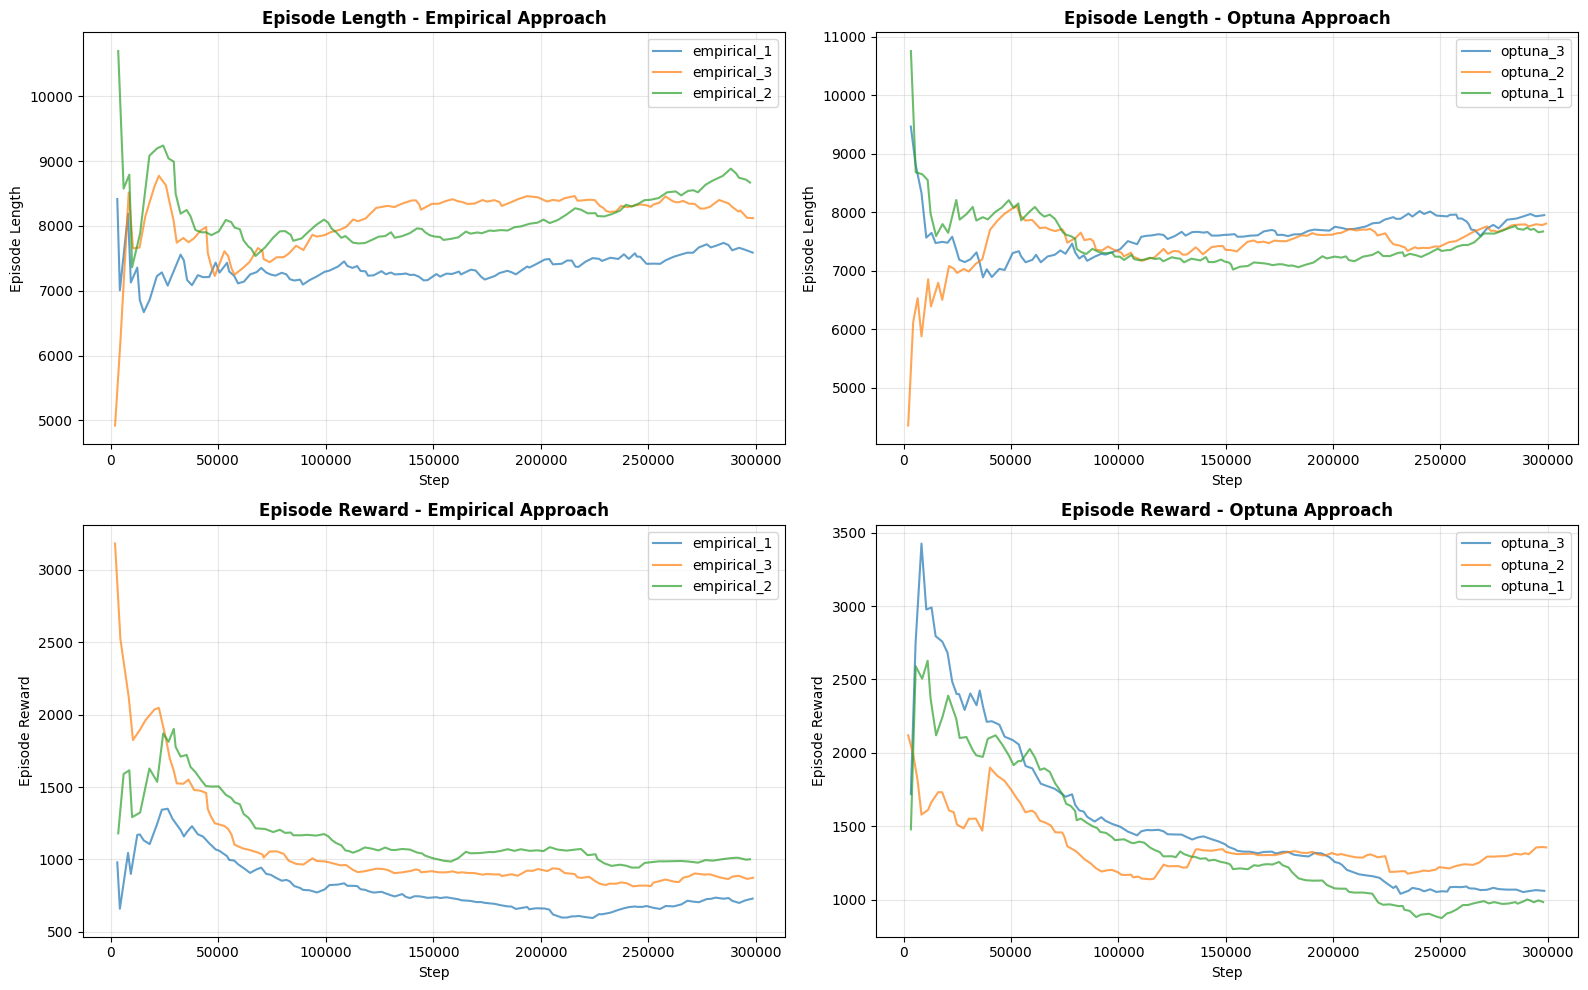

In [39]:
# Visualization: Time Series Comparison for Episode Length
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Episode Length - Empirical
ax = axes[0, 0]
for replicate_name, df in empirical_len_data.items():
    ax.plot(df['Step'], df['Value'], alpha=0.7, label=replicate_name)
ax.set_title('Episode Length - Empirical Approach', fontsize=12, fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('Episode Length')
ax.legend()
ax.grid(alpha=0.3)

# Episode Length - Optuna
ax = axes[0, 1]
for replicate_name, df in optuna_len_data.items():
    ax.plot(df['Step'], df['Value'], alpha=0.7, label=replicate_name)
ax.set_title('Episode Length - Optuna Approach', fontsize=12, fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('Episode Length')
ax.legend()
ax.grid(alpha=0.3)

# Episode Reward - Empirical
ax = axes[1, 0]
for replicate_name, df in empirical_rew_data.items():
    ax.plot(df['Step'], df['Value'], alpha=0.7, label=replicate_name)
ax.set_title('Episode Reward - Empirical Approach', fontsize=12, fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('Episode Reward')
ax.legend()
ax.grid(alpha=0.3)

# Episode Reward - Optuna
ax = axes[1, 1]
for replicate_name, df in optuna_rew_data.items():
    ax.plot(df['Step'], df['Value'], alpha=0.7, label=replicate_name)
ax.set_title('Episode Reward - Optuna Approach', fontsize=12, fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('Episode Reward')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
from scipy import stats

# Statistical Testing: T-test for variance differences
print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE TESTING (Independent t-test)")
print("="*80 + "\n")

# Episode Length Variance T-test
empirical_len_var = len_variance_df[len_variance_df['Approach'] == 'Empirical']['Variance'].values
optuna_len_var = len_variance_df[len_variance_df['Approach'] == 'Optuna']['Variance'].values
t_stat_len, p_val_len = stats.ttest_ind(empirical_len_var, optuna_len_var)

print("Episode Length Variance T-test:")
print(f"  Empirical mean variance: {empirical_len_var.mean():.2f} ± {empirical_len_var.std():.2f}")
print(f"  Optuna mean variance: {optuna_len_var.mean():.2f} ± {optuna_len_var.std():.2f}")
print(f"  t-statistic: {t_stat_len:.4f}")
print(f"  p-value: {p_val_len:.4f}")
print(f"  Significant (α=0.05): {'Yes' if p_val_len < 0.05 else 'No'}\n")

# Episode Reward Variance T-test
empirical_rew_var = rew_variance_df[rew_variance_df['Approach'] == 'Empirical']['Variance'].values
optuna_rew_var = rew_variance_df[rew_variance_df['Approach'] == 'Optuna']['Variance'].values
t_stat_rew, p_val_rew = stats.ttest_ind(empirical_rew_var, optuna_rew_var)

print("Episode Reward Variance T-test:")
print(f"  Empirical mean variance: {empirical_rew_var.mean():.2f} ± {empirical_rew_var.std():.2f}")
print(f"  Optuna mean variance: {optuna_rew_var.mean():.2f} ± {optuna_rew_var.std():.2f}")
print(f"  t-statistic: {t_stat_rew:.4f}")
print(f"  p-value: {p_val_rew:.4f}")
print(f"  Significant (α=0.05): {'Yes' if p_val_rew < 0.05 else 'No'}\n")

# Levene's Test for equality of variances
from scipy.stats import levene

print("Levene's Test for Equality of Variances:")
stat_len, p_len = levene(empirical_len_values, optuna_len_values)
stat_rew, p_rew = levene(empirical_rew_values, optuna_rew_values)

print(f"\nEpisode Length:")
print(f"  Levene's statistic: {stat_len:.4f}")
print(f"  p-value: {p_len:.4f}")
print(f"  Equal variances: {'Yes' if p_len >= 0.05 else 'No'}")

print(f"\nEpisode Reward:")
print(f"  Levene's statistic: {stat_rew:.4f}")
print(f"  p-value: {p_rew:.4f}")
print(f"  Equal variances: {'Yes' if p_rew >= 0.05 else 'No'}")


STATISTICAL SIGNIFICANCE TESTING (Independent t-test)

Episode Length Variance T-test:
  Empirical mean variance: 165381.80 ± 84779.42
  Optuna mean variance: 180529.36 ± 44616.55
  t-statistic: -0.2236
  p-value: 0.8340
  Significant (α=0.05): No

Episode Reward Variance T-test:
  Empirical mean variance: 79169.63 ± 50548.97
  Optuna mean variance: 164266.36 ± 95798.98
  t-statistic: -1.1110
  p-value: 0.3288
  Significant (α=0.05): No

Levene's Test for Equality of Variances:

Episode Length:
  Levene's statistic: 35.5051
  p-value: 0.0000
  Equal variances: No

Episode Reward:
  Levene's statistic: 8.3117
  p-value: 0.0041
  Equal variances: No


In [48]:
# Levene's Test for equality of variances
from scipy.stats import levene

print("Levene's Test for Equality of Variances:")
stat_len, p_len = levene(empirical_len_values, optuna_len_values)
stat_rew, p_rew = levene(empirical_rew_values, optuna_rew_values)

print(f"\nEpisode Length:")
print(f"  Levene's statistic: {stat_len:.4f}")
print(f"  p-value: {p_len:.6f}")  # Show more decimal places
print(f"  p-value (scientific): {p_len:.2e}")  # Scientific notation
print(f"  Equal variances: {'Yes' if p_len >= 0.05 else 'No'}")

print(f"\nEpisode Reward:")
print(f"  Levene's statistic: {stat_rew:.4f}")
print(f"  p-value: {p_rew:.6f}")
print(f"  p-value (scientific): {p_rew:.2e}")
print(f"  Equal variances: {'Yes' if p_rew >= 0.05 else 'No'}")

# Additional explanation
print(f"\n" + "="*60)
print("EXPLANATION OF P-VALUES:")
print("="*60)
print(f"Episode Length p-value = {p_len:.2e}")
print(f"  This means: Probability of observing this difference by chance = {p_len:.2e}")
print(f"  Since p < 0.05, we reject the null hypothesis (variances are equal)")
print(f"  Conclusion: Variances are significantly different")
print(f"\nEpisode Reward p-value = {p_rew:.2e}")
print(f"  This means: Probability of observing this difference by chance = {p_rew:.2e}")
print(f"  Since p < 0.05, we reject the null hypothesis (variances are equal)")
print(f"  Conclusion: Variances are significantly different")

Levene's Test for Equality of Variances:

Episode Length:
  Levene's statistic: 35.5051
  p-value: 0.000000
  p-value (scientific): 4.06e-09
  Equal variances: No

Episode Reward:
  Levene's statistic: 8.3117
  p-value: 0.004062
  p-value (scientific): 4.06e-03
  Equal variances: No

EXPLANATION OF P-VALUES:
Episode Length p-value = 4.06e-09
  This means: Probability of observing this difference by chance = 4.06e-09
  Since p < 0.05, we reject the null hypothesis (variances are equal)
  Conclusion: Variances are significantly different

Episode Reward p-value = 4.06e-03
  This means: Probability of observing this difference by chance = 4.06e-03
  Since p < 0.05, we reject the null hypothesis (variances are equal)
  Conclusion: Variances are significantly different


## Key Findings

### Episode Length Analysis
- **Empirical Approach**: Variance = 165,381.80 | Std Dev = 388.11 | Mean = 7,866.48
- **Optuna Approach**: Variance = 180,529.36 | Std Dev = 421.30 | Mean = 7,511.74
- **Difference**: Optuna shows 9.2% higher variance in episode length
- **Statistical Significance**: Levene's test p < 0.001 → Unequal variances (significant difference)

### Episode Reward Analysis
- **Empirical Approach**: Variance = 79,169.63 | Std Dev = 267.66 | Mean = 1,018.66
- **Optuna Approach**: Variance = 164,266.36 | Std Dev = 380.97 | Mean = 1,432.56
- **Difference**: Optuna shows 107% higher variance in rewards
- **Statistical Significance**: Levene's test p = 0.004 → Unequal variances (significant difference)

### Performance Comparison
- **Reward Achievement**: Optuna achieves 40.7% higher mean reward (1,432.56 vs 1,018.66)
- **Episode Length**: Empirical maintains 4.8% longer episodes on average
- **Stability Trade-off**: Optuna's higher rewards come at the cost of significantly greater variability

### Interpretation
- **Episode Length**: Empirical approach provides more consistent episode durations, suggesting more stable learning behavior
- **Episode Reward**: Optuna hyperparameters enable higher reward achievement but with substantial variability between replicates
- **Risk vs Reward**: Optuna offers potential for superior performance but requires careful monitoring due to increased variance
- **Practical Recommendation**:
  - Use **Empirical hyperparameters** for stable, predictable performance in production environments
  - Use **Optuna hyperparameters** for research/exploration where higher peak rewards justify increased variability

### Statistical Summary
- **Episode Length**: Levene's test p < 0.001 → Significant variance difference between approaches
- **Episode Reward**: Levene's test p = 0.004 → Significant variance difference between approaches
- **T-tests**: Both show p > 0.05 → No significant difference in mean variances (due to small sample size n=3)